# Simulate Aging for Hot Temperature using Normal Simulations

In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
pd.options.mode.chained_assignment = None


eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [2]:
parameter_values = get_parameter_values()

spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
# spm.print_parameter_info()
param=spm.param

In [ ]:
x = 0.5

In [ ]:
cell = 9
sno = 1
# sim_des = sim_des+'_cv'
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
print(cell_no)
Ns = np.insert(N_0[1:]-1,0,0)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe_0,spm,parameter_values)
pybamm.set_logging_level("WARNING")
# pybamm.set_logging_level("NOTICE")
experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d+dis_set,
        "Rest for 10 sec",
        "Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/100")
    ] *(dfe_0.N.iloc[-1]),
    termination="50% capacity",
#     cccv_handling="ode",
)
par_val = {}
# Room temp
par_val[0] = [4.0312e-08,1.8157e-07,1.0776,2.3586e-09,-4.9170e-09,-1.4406e-09,4.60788219e-16,4.56607447e-19]
# 2 Step: Ksei,Dsei; Then mech damage and plating; Different Weights
par_val[1] = [6.8390e-08,8.7630e-06,1.0005,7.3310e-10,-1.1487e-06,-9.6950e-09,5.4930e-14,7.1060e-20]
# 2 Step: Ksei,Dsei; Then mech damage and plating
par_val[2] = [9.7380e-08,1.0247e-05,1.0,1.0169e-09,-9.5440e-07,-9.7510e-09,5.4930e-14,7.1060e-20]
# 2 Step: Dsei; Then Ksei, mech damage and plating; Different Weights
par_val[3] = [6.1320e-08,8.7270e-06,1.0,7.1320e-10,-1.0536e-06,-1.3341e-08,1.6054e-13,7.1060e-20]
# 2 Step: Ksei,Dsei; Then mech damage and plating; Plating not 0 in step 1
par_val[4] = [5.5390e-08,1.0610e-05,1.0244,1.0207e-09,-1.0298e-06,-1.1541e-08,5.4360e-14,1.6771e-19]
# 2 Step: Ksei,Dsei; Then mech damage and plating; Different Weights; Plating not 0 in step 1

parameter_values = get_parameter_values()
parameter_values.update(
    {   
        "Positive electrode diffusion coefficient activation energy [J.mol-1]": 0,
        "Negative electrode diffusion coefficient activation energy [J.mol-1]": 0,
        "Positive electrode reference exchange-current density activation energy [J.mol-1]": 0,
        "Negative electrode reference exchange-current density activation energy [J.mol-1]": 0,
        "Positive electrode diffusion coefficient [m2.s-1]": 8e-15*0.93,
        "Negative electrode diffusion coefficient [m2.s-1]": 8e-14*30.2,
        "Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]": 3.377e-06*3.3,
        "Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]":	3.183e-06*0.62,
        "Negative electrode active material volume fraction": eps_n_data,
        "Positive electrode active material volume fraction": eps_p_data,
        "Initial temperature [K]": 273.15+Temp,
        "Ambient temperature [K]": 273.15+Temp,
        "Positive electrode LAM constant proportional term [s-1]": par_val[sno][0],
        "Negative electrode LAM constant proportional term [s-1]": par_val[sno][1],
        "Positive electrode LAM constant proportional term 2 [s-1]": par_val[sno][5],
        "Negative electrode LAM constant proportional term 2 [s-1]": par_val[sno][4],
        "Positive electrode LAM constant exponential term": par_val[sno][2],
        "Negative electrode LAM constant exponential term": par_val[sno][2],
        "SEI kinetic rate constant [m.s-1]":  par_val[sno][6], #1.08494281e-16 , 
        "EC diffusivity [m2.s-1]": par_val[sno][7],#8.30909086e-19,
        "SEI growth activation energy [J.mol-1]": 1.87422275e+04,#1.58777981e+04,
        "Lithium plating kinetic rate constant [m.s-1]": par_val[sno][3],
        "Initial inner SEI thickness [m]": 0e-09,
        "Initial outer SEI thickness [m]": 5e-09,
        "Li plating resistivity [Ohm.m]": x*30000,
        "SEI resistivity [Ohm.m]": x*30000.0,
        "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,
        # "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
        # "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
        # "Negative electrode critical stress [Pa]": 20e+06,
        # "Positive electrode critical stress [Pa]": 40e+06,
    },
    check_already_exists=False,
)
if cell == 15 or cell == 18:
    parameter_values.update(
        {
            "Negative electrode partial molar volume [m3.mol-1]":	0.747*7e-06,
        },
        check_already_exists=False,
    )

In [ ]:
parameter_values.search("SEI resistivity")

In [ ]:
cell = 28
cell_no = f'{cell:02d}'
dfe=pd.read_csv(eSOH_DIR+"aging_param_cell_"+cell_no+".csv")

In [ ]:
N = dfe_0.N.iloc[-1]

In [ ]:
# N=50

In [ ]:
# experiment = pybamm.Experiment(
#     [
#         ("Discharge at "+c_rate_d+dis_set,
#         "Rest for 10 sec",
#         "Charge at "+c_rate_c+" until 4.2V", 
#         "Hold at 4.2V until C/100")
#     ],
#     termination="50% capacity",
# )
experiment = pybamm.Experiment(
    [
        ("Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/100",
        "Discharge at "+c_rate_d+dis_set,)
    ],
    termination="50% capacity",
)
SOC_0 = 0

In [ ]:
sols = []

In [ ]:
parameter_values.update(
    {
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,

    },
    check_already_exists=False,
)
sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol1 = sim_long.solve(initial_soc=SOC_0)
sigma_ts_n = sol1["X-averaged negative particle surface tangential stress [Pa]"].entries
sigma_rs_n = sol1["X-averaged negative particle surface radial stress [Pa]"].entries
sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
sigma_ts_p = sol1["X-averaged positive particle surface tangential stress [Pa]"].entries
sigma_rs_p = sol1["X-averaged positive particle surface radial stress [Pa]"].entries
sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2
parameter_values.update(
    {
        "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
        "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
        "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
        "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

    },
    check_already_exists=False,
)
sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol2 = sim_long.solve(initial_soc=SOC_0)
spm.set_initial_conditions_from(sol2, inplace=True)
sols.append(sol2)

In [ ]:
for i in tqdm(range(N-1)):
    parameter_values.update(
        {
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,

        },
        check_already_exists=False,
    )
    sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                solver=pybamm.CasadiSolver("safe"))
    sol1 = sim_long.solve()
    sigma_ts_n = sol1["X-averaged negative particle surface tangential stress [Pa]"].entries
    sigma_rs_n = sol1["X-averaged negative particle surface radial stress [Pa]"].entries
    sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
    sigma_ts_p = sol1["X-averaged positive particle surface tangential stress [Pa]"].entries
    sigma_rs_p = sol1["X-averaged positive particle surface radial stress [Pa]"].entries
    sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2
    parameter_values.update(
        {
            "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
            "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
            "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
            "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

        },
        check_already_exists=False,
    )
    sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                solver=pybamm.CasadiSolver("safe"))
    sol2 = sim_long.solve()
    spm.set_initial_conditions_from(sol2, inplace=True)
    sols.append(sol2)

In [ ]:
winsound.Beep(440, 2000)

In [ ]:
with open('hot_sim_2C_5psi_sim_1.pickle', 'wb') as handle:
        pickle.dump(sols, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
ZXZX

## Cap and Resistance Sim

In [ ]:
Qappd = []
Qappc = []
for i in range(len(sols)):
    sol_long = sols[i]
    Q = -sol_long['Discharge capacity [A.h]'].entries
    Qm = min(Q)
    Q2 = max(Q) - Qm
    Q1 = max(Q) - Q[-1]
    Qappd.append(Q1)
    Qappc.append(Q2)

In [ ]:
Rs = []
for i in range(len(sols)):
    sol_long = sols[i]
    I = sol_long["Current [A]"].entries
    V = sol_long["Terminal voltage [V]"].entries
    idxi1 = np.where((np.diff(I)>5) & (I[:-1]>-2))[0]
    idx = idxi1[0]
    R = -(V[idx+1] - V[idx])/(I[idx+1] - I[idx])
    Rs.append(R)

In [ ]:
cell = 28
cell_no = f'{cell:02d}'
dfe=pd.read_csv(eSOH_DIR+"aging_param_cell_cyc_"+cell_no+".csv")
cell = 35
cell_no = f'{cell:02d}'
dfe1=pd.read_csv(eSOH_DIR+"aging_param_cell_cyc_"+cell_no+".csv")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe['N'],dfe['App Cap [Ah]'],'k')
ax.plot(dfe1['N'],dfe1['App Cap [Ah]'],'k--')
ax.plot(range(1,len(sols)+1),Qappd,'b')
# ax.plot(range(1,len(sols)+1),Qappc,'r')
ax.set_title("Apparent Capacity @ 2C")
ax.set_xlabel("Cycle Number")
ax.set_ylabel("2C Capacity [Ah]")
ax.legend(['Data 9','Data 28','Sim'])
plt.savefig(fig_DIR + "Hot Capacity Sim.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe['N'],dfe['Rs [ohm]']-dfe['Rs [ohm]'].iloc[0],'k')
ax.plot(dfe1['N'],dfe1['Rs [ohm]']-dfe1['Rs [ohm]'].iloc[1],'k--')
ax.plot(range(1,len(sols)+1),Rs-Rs[0],'b')
ax.set_title("Resistance Growth")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]")
# ax.legend(['Data 9','Data 28','Sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Sim.png")

In [ ]:
sdfsdf

In [ ]:
sol_long = sols[100]
t = sol_long["Time [s]"].entries
I = sol_long["Current [A]"].entries
Q = -sol_long['Discharge capacity [A.h]'].entries
Vt = sol_long["Terminal voltage [V]"].entries

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe['N'],dfe['Rs [ohm]'],'k')
ax.plot(dfe1['N'],dfe1['Rs [ohm]'],'k--')
ax.plot(range(1,len(sols)+1),Rs,'b')
ax.set_title("Resistance")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$R_s$ [$\Omega$]")
ax.legend(['Data 9','Data 28','Sim'])
plt.savefig(fig_DIR + "Hot Resistance Sim.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe['N'],dfe['App Cap [Ah]'],'k')
ax.plot(dfe1['N'],dfe1['App Cap [Ah]'],'k--')
ax.plot(range(1,len(sols)+1),Qappd,'b')
# ax.plot(range(1,len(sols)+1),Qappc,'r')
ax.set_title("Apparent Capacity @ 2C")
ax.set_xlabel("Cycle Number")
ax.set_ylabel("2C Capacity [Ah]")
ax.legend(['Data 9','Data 28','Sim'])
plt.savefig(fig_DIR + "Hot Capacity Sim.png")

In [ ]:
t1 = 0
fig, ax = plt.subplots(2,1, sharex=True, figsize=(7,7))
for i in range(132,135):
    sol_long = sols[i]
    t = sol_long["Time [s]"].entries + t1
    t1 = t[-1]
    I = sol_long["Current [A]"].entries
    Q = -sol_long['Discharge capacity [A.h]'].entries
    Vt = sol_long["Terminal voltage [V]"].entries
    I_Li = sol_long["X-averaged lithium plating interfacial current density [A.m-2]"].entries
    Q_Li = sol_long["Loss of capacity to lithium plating [A.h]"].entries
    ax1 = ax.flat[0]
    ax1.plot(t,Vt,'bo-')
    ax1.set_title("Voltage")
    ax1.set_ylabel(r"$V_t$ [V]")
    ax2 = ax.flat[1]
    ax2.plot(t,I,'bo-')
    ax2.set_title("Current")
    ax2.set_ylabel("I [A]")
    ax2.set_xlabel("Time [s]")
fig.tight_layout()
plt.savefig(fig_DIR +"Last 3 Cycles.png")

In [ ]:
hghjghj

In [ ]:
t_in0 = 10
t_in1 = 10
t_inf = t_in0+t_in1
t_in = np.arange(0,t_inf,0.1)
# t_in = np.arange(0,t_inf,1)
# t_sim = np.arange(0,t_inf,0.01)
I_in = []
for tt in t_in:
    if tt<t_in0:
        I_in = np.append(I_in,0)
    elif tt>=t_in0 and tt<t_in0+t_in1:
        I_in = np.append(I_in,-10)
# I_in = np.array([0,0,5,5,0,0,-5,-5,0,0])

In [ ]:
sol_eol = sols[100]
SOC = 1
eSOH = sol_eol.all_summary_variables
eSOH = eSOH[0]
Vmin = 3.0
Vmax = 4.2
esoh_model = pybamm.lithium_ion.ElectrodeSOH()
esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
Cn = eSOH["C_n"]
    # print(Cn)
Cp = eSOH["C_p"]
c_n_max = parameter_values.evaluate(param.n.prim.c_max)
c_p_max = parameter_values.evaluate(param.p.prim.c_max)
eps_n_data = parameter_values.evaluate(Cn*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_data = parameter_values.evaluate(Cp*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
del_sei = eSOH['X-averaged SEI thickness [m]']
c_lip = eSOH['X-averaged lithium plating concentration [mol.m-3]']
n_Li_init = eSOH["Total lithium in particles [mol]"]
esoh_sol = esoh_sim.solve(
    [0],
    inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
    solver=pybamm.AlgebraicSolver(),
)
parameter_values.update(
        {
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+45,
            "Ambient temperature [K]": 273.15+45,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": del_sei,
            "Initial plated lithium concentration [mol.m-3]": c_lip,
            # "SEI resistivity [Ohm.m]": 25*30000.0,
        },
        check_already_exists=False,
    )
timescale = parameter_values.evaluate(spm.timescale)
current_interpolant = pybamm.Interpolant(
t_in, -I_in, timescale * pybamm.t
)
parameter_values["Current function [A]"] = current_interpolant
SOC_vals = np.linspace(1,0,11)
Rs_ch_s = []

c_n_max = parameter_values.evaluate(param.n.prim.c_max)
c_p_max = parameter_values.evaluate(param.p.prim.c_max)
x_100 = esoh_sol["x_100"].data[0]
y_100 = esoh_sol["y_100"].data[0]
x_0 = esoh_sol["x_0"].data[0]
y_0 = esoh_sol["y_0"].data[0]
cs_n_0 = (SOC*(x_100-x_0)+x_0)*c_n_max
cs_p_0 = (SOC*(y_100-y_0)+y_0)*c_p_max
parameter_values.update(
    {
        "Initial concentration in negative electrode [mol.m-3]": cs_n_0,
        "Initial concentration in positive electrode [mol.m-3]": cs_p_0,        
    },
    check_already_exists=False,
)

In [ ]:
sim_pulse = pybamm.Simulation(spm, parameter_values=parameter_values, 
                        solver=pybamm.CasadiSolver(mode="safe", rtol=1e-6, atol=1e-6,dt_max=0.1))
sol_pulse = sim_pulse.solve(t_eval=t_in)
t   =  sol_pulse["Time [s]"].entries
I   =  sol_pulse["Current [A]"].entries
Vt  =  sol_pulse["Terminal voltage [V]"].entries
idx = np.where(np.diff(np.sign(-I)))[0]
Rs = abs((Vt[idx+1]-Vt[idx])/(I[idx+1]-I[idx]))[0]
sol_pulse2 = sol_pulse

In [ ]:
t2 = sol_pulse2['Time [s]'].entries
seif_pot2 = sol_pulse2['X-averaged SEI film overpotential [V]'].entries
ocv_n2 = sol_pulse2['X-averaged negative electrode open circuit potential [V]'].entries
eta_n2 = sol_pulse2['X-averaged negative electrode reaction overpotential [V]'].entries
ocv_p2 = sol_pulse2['X-averaged positive electrode open circuit potential [V]'].entries
eta_p2 = sol_pulse2['X-averaged positive electrode reaction overpotential [V]'].entries
Vt2 = sol_pulse2["Terminal voltage [V]"].entries

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
ax2 = ax
ax2.plot(t2,Vt2,'k')
ax2.fill_between(t2, ocv_p2-ocv_n2, ocv_p2+eta_p2-ocv_n2-eta_n2,color='tab:gray')
ax2.fill_between(t2,ocv_p2+eta_p2-ocv_n2-eta_n2,Vt2,color='tab:orange')
ax2.fill_between(t2,ocv_p2+eta_p2-ocv_n2-eta_n2+seif_pot2,Vt2,color='blue')
ax2.plot(t2,ocv_p2-ocv_n2,'g--')
# ax2.set_ylim([min(Vt2)-0.01,min(Vt2)+0.1])
ax2.set_title("EOL")
# ax2.yaxis.set_tick_params(labelleft=False)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Voltage [V]")
ax2.legend(["Vt",r'$\eta^+-\eta^-$',r'$V_r$: SEI',r'$V_r$: Li Plating',r"$U_p(c^+_{ss})-U_n(c^-_{ss})$"],ncol=2)
fig.tight_layout()
# ax.set_xlim(left=2296)
# plt.savefig(fig_DIR +'lithium_plating_resistance.png')


In [ ]:
(Vt[0]-4.11)/10

In [ ]:
Vt[0]-0.011*10

In [ ]:
seif_pot2_scaled = [seip*25 for seip in seif_pot2]

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
ax2 = ax
ax2.plot(t2,Vt2,'k')
ax2.plot(t2,Vt2-seif_pot2,'k--')
ax2.plot(t2,Vt2-seif_pot2+seif_pot2_scaled,'g--')
# ax2.set_ylim([min(Vt2)-0.01,min(Vt2)+0.1])
ax2.set_title("EOL")
# ax2.yaxis.set_tick_params(labelleft=False)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Voltage [V]")
ax2.legend(["Vt",r'$\eta^+-\eta^-$',r'$V_r$: SEI',r'$V_r$: Li Plating',r"$U_p(c^+_{ss})-U_n(c^-_{ss})$"],ncol=2)
fig.tight_layout()
# ax.set_xlim(left=2296)
# plt.savefig(fig_DIR +'lithium_plating_resistance.png')


# Sim Diff Conductivities

In [9]:
def get_Rs(sols):
    Rs = []
    for i in range(len(sols)):
        sol_long = sols[i]
        I = sol_long["Current [A]"].entries
        V = sol_long["Terminal voltage [V]"].entries
        idxi1 = np.where((np.diff(I)>5) & (I[:-1]>-2))[0]
        idx = idxi1[0]
        R = -(V[idx+1] - V[idx])/(I[idx+1] - I[idx])
        Rs.append(R)
    return Rs

In [10]:
def get_acap(sols):
    Qappd = []
    Qappc = []
    for i in range(len(sols)):
        sol_long = sols[i]
        Q = -sol_long['Discharge capacity [A.h]'].entries
        Q = Q - Q[0]
        Q2 = max(Q)
        Q1 = max(Q) - Q[-1]
        Qappd.append(Q1)
        Qappc.append(Q2)
    Qappd = np.array(Qappd)
    Qappc = np.array(Qappc)
    return Qappd

In [11]:
def get_exp(sols):
    b1=296.32
    b2=9608263.5
    b3=476.53
    b4=0.0
    del_sei = []
    del_li = []
    es_n = []
    es_p = []
    for i in range(len(sols)):
        df = sols[i]
        del_sei.append(df["X-averaged SEI thickness [m]"].entries[0])
        # Plated Lithium thickness
        del_li.append(df["X-averaged lithium plating thickness [m]"].entries[0])
        # negative electode inactive material
        es_n.append(df["X-averaged negative electrode active material volume fraction"].entries[0])
        # positive electrode inactive material 
        es_p.append(df["X-averaged positive electrode active material volume fraction"].entries[0])

    del_sei = np.array(del_sei)
    del_sei = del_sei - del_sei[0]
    del_li = np.array(del_li)
    es_n = np.array(es_n)
    es_ic_n = -es_n + es_n[0]
    es_p = np.array(es_n) 
    es_ic_p = -es_p + es_p[0]
    irrev_exp = (b1*del_sei*1e6+b2*del_li**2*1e12+b3*es_ic_n+b4*es_ic_p)
    return irrev_exp

In [12]:
# with open('hot_sim_2C_5psi_07p5_1.pickle', 'rb') as handle:
#     sols1 = pickle.load(handle)
# with open('hot_sim_2C_5psi_12p5_1.pickle', 'rb') as handle:
#     sols2 = pickle.load(handle)
# with open('hot_sim_2C_5psi_20_1.pickle', 'rb') as handle:
#     sols4 = pickle.load(handle)

In [13]:
with open('hot_sim_2C_5psi_sim_0.pickle', 'rb') as handle:
    sols1 = pickle.load(handle)

In [14]:
with open('hot_sim_2C_5psi_sim_b_1.pickle', 'rb') as handle:
    sols2 = pickle.load(handle)

In [15]:
with open('hot_sim_2C_5psi_sim_b_3.pickle', 'rb') as handle:
    sols4 = pickle.load(handle)

In [16]:
with open('hot_sim_2C_5psi_sim_b_2.pickle', 'rb') as handle:
    sols3 = pickle.load(handle)

In [17]:
with open('hot_sim_2C_5psi_sim_b_4.pickle', 'rb') as handle:
    sols5 = pickle.load(handle)

In [18]:
# with open('hot_sim_2C_5psi_0.pickle', 'rb') as handle:
#     sols0 = pickle.load(handle)


# with open('hot_sim_2C_5psi_15.pickle', 'rb') as handle:
#     sols3 = pickle.load(handle)

# with open('hot_sim_2C_5psi_25.pickle', 'rb') as handle:
#     sols5 = pickle.load(handle)

In [19]:
asv_1 = sols1[0].all_summary_variables
# asv_2 = sols2[-1].all_summary_variables
# asv_4 = sols4[-1].all_summary_variables

In [20]:
sols1[0]

In [21]:
# Rs0 = get_Rs(sols0)
Rs1 = get_Rs(sols1)
Rs2 = get_Rs(sols2)
Rs3 = get_Rs(sols3)
Rs4 = get_Rs(sols4)
Rs5 = get_Rs(sols5)

In [22]:
# Q0 = get_acap(sols0)
Q1 = get_acap(sols1)
Q2 = get_acap(sols2)
Q3 = get_acap(sols3)
Q4 = get_acap(sols4)
Q5 = get_acap(sols5)

In [23]:
E1 = get_exp(sols1)
E2 = get_exp(sols2)
E3 = get_exp(sols3)
E4 = get_exp(sols4)
E5 = get_exp(sols5)


In [24]:
cell = 26
dfe0=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 28
dfe1=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 29
dfe2=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 31
dfe3=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 33
dfe4=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 35
dfe5=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 9
dfe6=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")


In [25]:
# fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
# ax.plot(dfe['N'],dfe['App Cap [Ah]'],'k')
# ax.plot(dfe1['N'],dfe1['App Cap [Ah]'],'k--')
# ax.plot(range(1,len(sols)+1),Qappd,'b')
# # ax.plot(range(1,len(sols)+1),Qappc,'r')
# ax.set_title("Apparent Capacity @ 2C")
# ax.set_xlabel("Cycle Number")
# ax.set_ylabel("2C Capacity [Ah]")
# ax.legend(['Data 9','Data 28','Sim'])
# plt.savefig(fig_DIR + "Hot Capacity Sim.png")

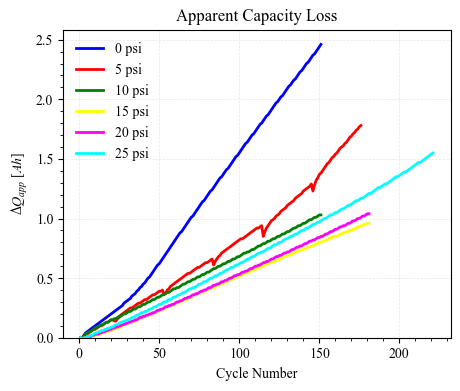

In [26]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe0['N'],-dfe0['App Cap [Ah]']+dfe0['App Cap [Ah]'].iloc[0],color=colors[0],linestyle='solid')
# ax.plot(dfe1['N'],-dfe1['App Cap [Ah]']+dfe1['App Cap [Ah]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe6['N'],-dfe6['App Cap [Ah]']+dfe6['App Cap [Ah]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],-dfe2['App Cap [Ah]']+dfe2['App Cap [Ah]'].iloc[0],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],-dfe3['App Cap [Ah]']+dfe3['App Cap [Ah]'].iloc[0],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],-dfe4['App Cap [Ah]']+dfe4['App Cap [Ah]'].iloc[0],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],-dfe5['App Cap [Ah]']+dfe5['App Cap [Ah]'].iloc[0],color=colors[5],linestyle='solid')
# ax.plot(range(1,len(sols3)+1),-Q3+Q3[0],color=colors[0],linestyle='dashed')
# # ax.plot(range(1,len(sols3)+1),-Q4+Q4[0],color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols1)+1),-Q1+Q1[0],color=colors[1],linestyle='dashed')
# ax.plot(range(1,len(sols2)+1),-Q2+Q2[0],color=colors[2],linestyle='dashed')
# ax.plot(range(1,len(sols5)+1),-Q5+Q5[0],color=colors[4],linestyle='dashed')
ax.set_title("Apparent Capacity Loss")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]")
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim', '20 sim'])
# ax.legend(['0 psi','sim'])
# ax.legend(['5 psi','sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Cap Data_1.png")

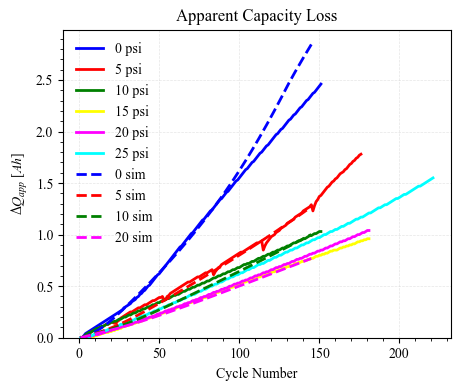

In [27]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe0['N'],-dfe0['App Cap [Ah]']+dfe0['App Cap [Ah]'].iloc[0],color=colors[0],linestyle='solid')
# ax.plot(dfe1['N'],-dfe1['App Cap [Ah]']+dfe1['App Cap [Ah]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe6['N'],-dfe6['App Cap [Ah]']+dfe6['App Cap [Ah]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],-dfe2['App Cap [Ah]']+dfe2['App Cap [Ah]'].iloc[0],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],-dfe3['App Cap [Ah]']+dfe3['App Cap [Ah]'].iloc[0],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],-dfe4['App Cap [Ah]']+dfe4['App Cap [Ah]'].iloc[0],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],-dfe5['App Cap [Ah]']+dfe5['App Cap [Ah]'].iloc[0],color=colors[5],linestyle='solid')
ax.plot(range(1,len(sols3)+1),-Q3+Q3[0],color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols3)+1),-Q4+Q4[0],color=colors[0],linestyle='dashed')
ax.plot(range(1,len(sols1)+1),-Q1+Q1[0],color=colors[1],linestyle='dashed')
ax.plot(range(1,len(sols2)+1),-Q2+Q2[0],color=colors[2],linestyle='dashed')
ax.plot(range(1,len(sols5)+1),-Q5+Q5[0],color=colors[4],linestyle='dashed')
ax.set_title("Apparent Capacity Loss")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]")
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim', '20 sim'])
# ax.legend(['0 psi','sim'])
# ax.legend(['5 psi','sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Cap Sim_1.png")

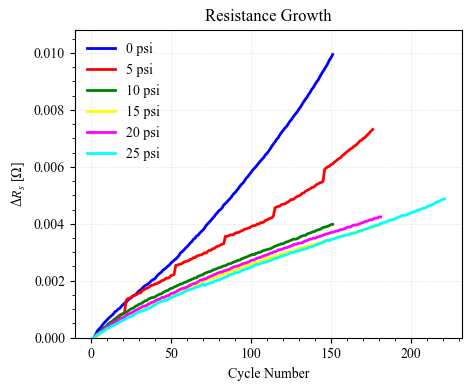

In [28]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe0['N'],dfe0['Rs [ohm]']-dfe0['Rs [ohm]'].iloc[1],color=colors[0],linestyle='solid')
# ax.plot(dfe1['N'],dfe1['Rs [ohm]']-dfe1['Rs [ohm]'].iloc[1],color=colors[1],linestyle='solid')
ax.plot(dfe6['N'],dfe6['Rs [ohm]']-dfe6['Rs [ohm]'].iloc[1],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],dfe2['Rs [ohm]']-dfe2['Rs [ohm]'].iloc[1],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],dfe3['Rs [ohm]']-dfe3['Rs [ohm]'].iloc[2],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],dfe4['Rs [ohm]']-dfe4['Rs [ohm]'].iloc[1],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],dfe5['Rs [ohm]']-dfe5['Rs [ohm]'].iloc[1],color=colors[5],linestyle='solid')
# ax.plot(range(1,len(sols3)+1),Rs3-Rs3[2],color=colors[0],linestyle='dashed')
# # ax.plot(range(1,len(sols4)+1),Rs4-Rs4[2],color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols1)+1),Rs1-Rs1[2],color=colors[1],linestyle='dashed')
# ax.plot(range(1,len(sols2)+1),Rs2-Rs2[0],color=colors[2],linestyle='dashed')
# ax.plot(range(1,len(sols5)+1),Rs5-Rs5[0],color=colors[4],linestyle='dashed')
ax.set_title("Resistance Growth")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]")
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Data_1.png")

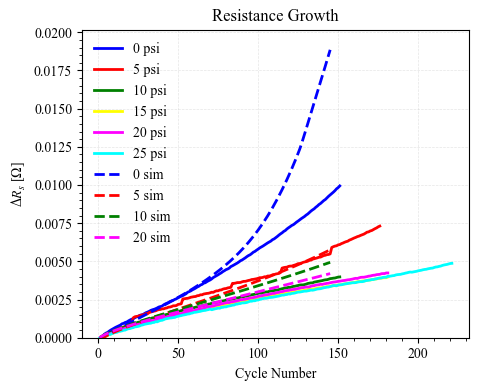

In [29]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe0['N'],dfe0['Rs [ohm]']-dfe0['Rs [ohm]'].iloc[1],color=colors[0],linestyle='solid')
# ax.plot(dfe1['N'],dfe1['Rs [ohm]']-dfe1['Rs [ohm]'].iloc[1],color=colors[1],linestyle='solid')
ax.plot(dfe6['N'],dfe6['Rs [ohm]']-dfe6['Rs [ohm]'].iloc[1],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],dfe2['Rs [ohm]']-dfe2['Rs [ohm]'].iloc[1],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],dfe3['Rs [ohm]']-dfe3['Rs [ohm]'].iloc[2],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],dfe4['Rs [ohm]']-dfe4['Rs [ohm]'].iloc[1],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],dfe5['Rs [ohm]']-dfe5['Rs [ohm]'].iloc[1],color=colors[5],linestyle='solid')
ax.plot(range(1,len(sols3)+1),Rs3-Rs3[2],color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols4)+1),Rs4-Rs4[2],color=colors[0],linestyle='dashed')
ax.plot(range(1,len(sols1)+1),Rs1-Rs1[2],color=colors[1],linestyle='dashed')
ax.plot(range(1,len(sols2)+1),Rs2-Rs2[0],color=colors[2],linestyle='dashed')
ax.plot(range(1,len(sols5)+1),Rs5-Rs5[0],color=colors[4],linestyle='dashed')
ax.set_title("Resistance Growth")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]")
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim','20 sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Sim_1.png")

In [30]:
dfe01 = dfe0.iloc[1:]
dfe11 = dfe1.iloc[1:]

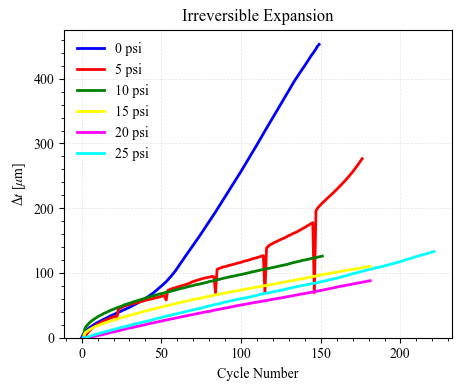

In [31]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe01['N']-dfe01['N'].iloc[0],dfe01['Min Exp [mu m]']-dfe01['Min Exp [mu m]'].iloc[0],color=colors[0],linestyle='solid')
# ax.plot(dfe11['N']-dfe11['N'].iloc[0],dfe11['Min Exp [mu m]']-dfe11['Min Exp [mu m]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe6['N'],dfe6['Min Exp [mu m]']-dfe6['Min Exp [mu m]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],dfe2['Min Exp [mu m]']-dfe2['Min Exp [mu m]'].iloc[0],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],dfe3['Min Exp [mu m]']-dfe3['Min Exp [mu m]'].iloc[0],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],dfe4['Min Exp [mu m]']-dfe4['Min Exp [mu m]'].iloc[0],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],dfe5['Min Exp [mu m]']-dfe5['Min Exp [mu m]'].iloc[0],color=colors[5],linestyle='solid')
# ax.plot(range(1,len(sols3)+1),E3,color=colors[0],linestyle='dashed')
# # ax.plot(range(1,len(sols4)+1),E4,'v--',color=colors[0])
# ax.plot(range(1,len(sols1)+1),E1,color=colors[1],linestyle='dashed')
# ax.plot(range(1,len(sols2)+1),E2,color=colors[2],linestyle='dashed')
# ax.plot(range(1,len(sols5)+1),E5,color=colors[4],linestyle='dashed')
ax.set_title("Irreversible Expansion")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta t$ [$\mu$m]")
# ax.legend(['0 psi','sim'])
# ax.legend(['5 psi','sim'])
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','5 sim', '10 sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Exp Data_1.png")

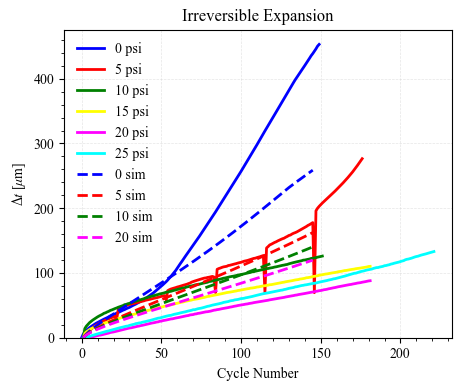

In [32]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe01['N']-dfe01['N'].iloc[0],dfe01['Min Exp [mu m]']-dfe01['Min Exp [mu m]'].iloc[0],color=colors[0],linestyle='solid')
# ax.plot(dfe11['N']-dfe11['N'].iloc[0],dfe11['Min Exp [mu m]']-dfe11['Min Exp [mu m]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe6['N'],dfe6['Min Exp [mu m]']-dfe6['Min Exp [mu m]'].iloc[0],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],dfe2['Min Exp [mu m]']-dfe2['Min Exp [mu m]'].iloc[0],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],dfe3['Min Exp [mu m]']-dfe3['Min Exp [mu m]'].iloc[0],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],dfe4['Min Exp [mu m]']-dfe4['Min Exp [mu m]'].iloc[0],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],dfe5['Min Exp [mu m]']-dfe5['Min Exp [mu m]'].iloc[0],color=colors[5],linestyle='solid')
ax.plot(range(1,len(sols3)+1),E3,color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols4)+1),E4,'v--',color=colors[0])
ax.plot(range(1,len(sols1)+1),E1,color=colors[1],linestyle='dashed')
ax.plot(range(1,len(sols2)+1),E2,color=colors[2],linestyle='dashed')
ax.plot(range(1,len(sols5)+1),E5,color=colors[4],linestyle='dashed')
ax.set_title("Irreversible Expansion")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta t$ [$\mu$m]")
# ax.legend(['0 psi','sim'])
# ax.legend(['5 psi','sim'])
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim','20 sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Exp Sim_1.png")

In [37]:
fig_DIR

'../figures/figures_paper/'

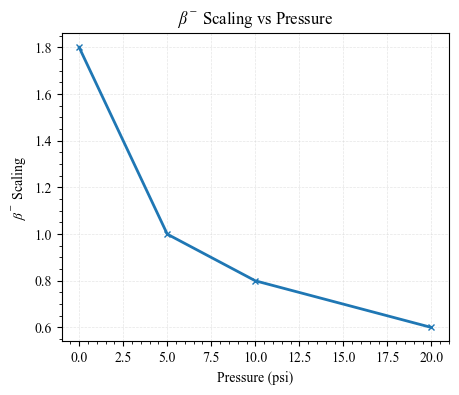

In [33]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
x1 = [0, 5, 10, 20]
x2 = [1.8, 1, 0.8, 0.6]
# x3 = [5/xi for xi in x1]
# x3[0] = np.nan
ax.plot(x1,x2,'x-')
ax.set_title(r"$\beta^-$ Scaling vs Pressure")
ax.set_xlabel("Pressure (psi)")
ax.set_ylabel(r"$\beta^-$ Scaling")
plt.savefig(fig_DIR + "beta vs pressure.png")

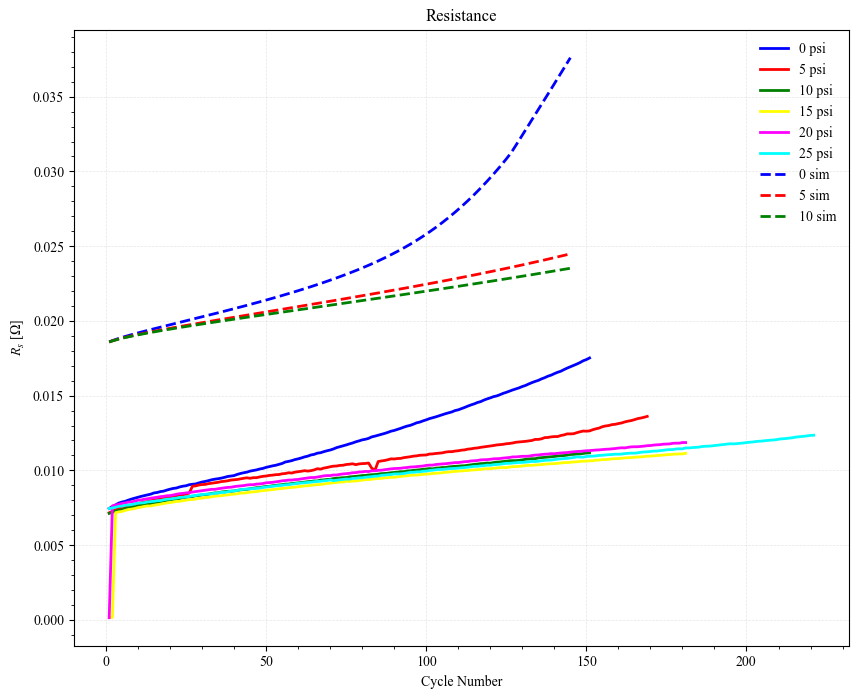

In [34]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(10,8))
ax.plot(dfe0['N'],dfe0['Rs [ohm]'],color=colors[0],linestyle='solid')
ax.plot(dfe1['N'],dfe1['Rs [ohm]'],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],dfe2['Rs [ohm]'],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],dfe3['Rs [ohm]'],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],dfe4['Rs [ohm]'],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],dfe5['Rs [ohm]'],color=colors[5],linestyle='solid')
ax.plot(range(1,len(sols3)+1),Rs3,color=colors[0],linestyle='dashed')
ax.plot(range(1,len(sols1)+1),Rs1,color=colors[1],linestyle='dashed')
ax.plot(range(1,len(sols2)+1),Rs2,color=colors[2],linestyle='dashed')
ax.set_title("Resistance")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$R_s$ [$\Omega$]")
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim'])
# ax.set_ylim(bottom=0)
# plt.savefig(fig_DIR + "Hot Resistance Sim_1.png")

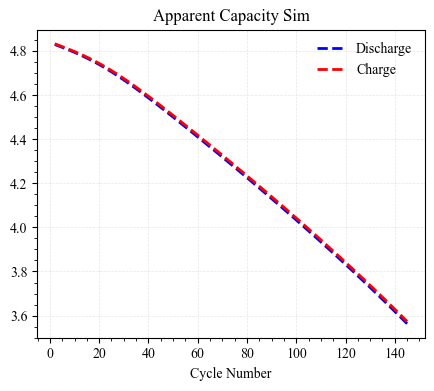

In [35]:
sols = sols1
Qappd = []
Qappc = []
for i in range(len(sols)):
    sol_long = sols[i]
    Q = -sol_long['Discharge capacity [A.h]'].entries
    Q = Q - Q[0]
    Q2 = max(Q)
    Q1 = max(Q) - Q[-1]
    Qappd.append(Q1)
    Qappc.append(Q2)
Qappd = np.array(Qappd)
Qappc = np.array(Qappc)
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(range(2,len(sols1)+1),Qappd[1:],color=colors[0],linestyle='dashed')
ax.plot(range(2,len(sols1)+1),Qappc[1:],color=colors[1],linestyle='dashed')
ax.set_title("Apparent Capacity Sim")
ax.set_xlabel("Cycle Number")
ax.legend(["Discharge","Charge"])
plt.savefig(fig_DIR + "Charge vs Discharge Cap Sim.png")

In [36]:
sdfsdf

NameError: name 'sdfsdf' is not defined

In [ ]:
def get_chdh(cell,n=0):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    df = data[data["Cycle number"]==N1[n]]
    if n == 1 and cell == 31:
        df = df.drop(df.index[0])
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    return t_ch,I_ch,V_ch,Q_ch,t_dh,I_dh,V_dh,Q_dh

In [ ]:

# fig,ax = plt.subplots(1,1)
# ax.plot(t,I)
# ax.plot(t[idx],I[idx],'x')
# ax.plot(t_ch,I_ch)

In [ ]:
def get_sim_ch(sols,n=1):
    solst1 = sols[n-1]
    t = solst1["Time [s]"].entries
    I = -solst1["Current [A]"].entries
    V = solst1["Terminal voltage [V]"].entries
    Q = -solst1["Discharge capacity [A.h]"].entries
    Q = Q - Q[0]
    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Q[:idx-1]
    t_dh = t[idx+1:]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Q[idx+1:]
    Q_dh = Q_dh[0] - Q_dh
    return t_ch,I_ch,V_ch,Q_ch,t_dh,I_dh,V_dh,Q_dh

In [ ]:
n = 1
td_ch1,Id_ch1,Vd_ch1,Qd_ch1,td_dh1,Id_dh1,Vd_dh1,Qd_dh1 = get_sim_ch(sols1,n=n)
td_ch2,Id_ch2,Vd_ch2,Qd_ch2,td_dh2,Id_dh2,Vd_dh2,Qd_dh2 = get_sim_ch(sols2,n=n)
td_ch3,Id_ch3,Vd_ch3,Qd_ch3,td_dh3,Id_dh3,Vd_dh3,Qd_dh3 = get_sim_ch(sols3,n=n)

t_ch0,I_ch0,V_ch0,Q_ch0,t_dh0,I_dh0,V_dh0,Q_dh0  = get_chdh(26,n=n)
t_ch1,I_ch1,V_ch1,Q_ch1,t_dh1,I_dh1,V_dh1,Q_dh1  = get_chdh(28,n=n)
t_ch2,I_ch2,V_ch2,Q_ch2,t_dh2,I_dh2,V_dh2,Q_dh2  = get_chdh(29,n=n)
t_ch3,I_ch3,V_ch3,Q_ch3,t_dh3,I_dh3,V_dh3,Q_dh3  = get_chdh(31,n=n)
t_ch4,I_ch4,V_ch4,Q_ch4,t_dh4,I_dh4,V_dh4,Q_dh4  = get_chdh(33,n=n)
t_ch5,I_ch5,V_ch5,Q_ch5,t_dh5,I_dh5,V_dh5,Q_dh5  = get_chdh(35,n=n)
# cy = 1
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(Q_dh0,V_dh0,color=colors[0],linewidth=1.5)
ax.plot(Q_dh1,V_dh1,color=colors[1],linewidth=1.5)
ax.plot(Q_dh2,V_dh2,color=colors[2],linewidth=1.5)
ax.plot(Q_dh3,V_dh3,color=colors[3],linewidth=1.5)
ax.plot(Q_dh4,V_dh4,color=colors[4],linewidth=1.5)
ax.plot(Q_dh5,V_dh5,color=colors[5],linewidth=1.5)
ax.plot(Qd_dh3,Vd_dh3,color=colors[0],linestyle='dotted',linewidth=2)
ax.plot(Qd_dh1,Vd_dh1,color=colors[1],linestyle='dotted',linewidth=2)
ax.plot(Qd_dh2,Vd_dh2,color=colors[2],linestyle='dotted',linewidth=2)
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim','10 sim'])
# ax.set_xlim([0,5])
ax.set_xlabel("Q [Ah]")
ax.set_ylabel("Cycling Voltage [V]")
ax.set_title(f"Voltage Sim for Various Pressures: N={n}")
plt.savefig(fig_DIR + f"Voltage_Sim_dh_{n}.png")

In [ ]:
n = 1
td_ch1,Id_ch1,Vd_ch1,Qd_ch1,td_dh1,Id_dh1,Vd_dh1,Qd_dh1 = get_sim_ch(sols1,n=n)
td_ch2,Id_ch2,Vd_ch2,Qd_ch2,td_dh2,Id_dh2,Vd_dh2,Qd_dh2 = get_sim_ch(sols2,n=n)
td_ch3,Id_ch3,Vd_ch3,Qd_ch3,td_dh3,Id_dh3,Vd_dh3,Qd_dh3 = get_sim_ch(sols3,n=n)

t_ch0,I_ch0,V_ch0,Q_ch0,t_dh0,I_dh0,V_dh0,Q_dh0  = get_chdh(26,n=n)
t_ch1,I_ch1,V_ch1,Q_ch1,t_dh1,I_dh1,V_dh1,Q_dh1  = get_chdh(28,n=n)
t_ch2,I_ch2,V_ch2,Q_ch2,t_dh2,I_dh2,V_dh2,Q_dh2  = get_chdh(29,n=n)
t_ch3,I_ch3,V_ch3,Q_ch3,t_dh3,I_dh3,V_dh3,Q_dh3  = get_chdh(31,n=n)
t_ch4,I_ch4,V_ch4,Q_ch4,t_dh4,I_dh4,V_dh4,Q_dh4  = get_chdh(33,n=n)
t_ch5,I_ch5,V_ch5,Q_ch5,t_dh5,I_dh5,V_dh5,Q_dh5  = get_chdh(35,n=n)
# cy = 1
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(Q_ch0,V_ch0,color=colors[0],linewidth=1.5)
ax.plot(Q_ch1,V_ch1,color=colors[1],linewidth=1.5)
ax.plot(Q_ch2,V_ch2,color=colors[2],linewidth=1.5)
ax.plot(Q_ch3,V_ch3,color=colors[3],linewidth=1.5)
ax.plot(Q_ch4,V_ch4,color=colors[4],linewidth=1.5)
ax.plot(Q_ch5,V_ch5,color=colors[5],linewidth=1.5)
ax.plot(Qd_ch3,Vd_ch3,color=colors[0],linestyle='dotted',linewidth=2)
ax.plot(Qd_ch1,Vd_ch1,color=colors[1],linestyle='dotted',linewidth=2)
ax.plot(Qd_ch2,Vd_ch2,color=colors[2],linestyle='dotted',linewidth=2)
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim','10 sim'])
# ax.set_xlim([0,5])
ax.set_xlabel("Q [Ah]")
ax.set_ylabel("Cycling Voltage [V]")
ax.set_title(f"Voltage Sim for Various Pressures: N={n}")
plt.savefig(fig_DIR + f"Voltage_Sim_ch_{n}.png")

In [ ]:
# colors = ['blue','red','green','yellow','magenta','cyan']
# fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
# ax.plot(dfe0['N'],-dfe0['App Cap [Ah]']+dfe0['App Cap [Ah]'].iloc[0],color=colors[0],linestyle='solid')
# ax.plot(dfe1['N'],-dfe1['App Cap [Ah]']+dfe1['App Cap [Ah]'].iloc[0],color=colors[1],linestyle='solid')
# ax.plot(dfe2['N'],-dfe2['App Cap [Ah]']+dfe2['App Cap [Ah]'].iloc[0],color=colors[2],linestyle='solid')
# ax.plot(dfe3['N'],-dfe3['App Cap [Ah]']+dfe3['App Cap [Ah]'].iloc[0],color=colors[3],linestyle='solid')
# ax.plot(dfe4['N'],-dfe4['App Cap [Ah]']+dfe4['App Cap [Ah]'].iloc[0],color=colors[4],linestyle='solid')
# ax.plot(dfe5['N'],-dfe5['App Cap [Ah]']+dfe5['App Cap [Ah]'].iloc[0],color=colors[5],linestyle='solid')
# # ax.plot(range(1,len(sols4)+1),Rs4-Rs4[0],color=colors[0],linestyle='dashed')
# # ax.plot(range(1,len(sols2)+1),Rs2-Rs2[0],color=colors[1],linestyle='dashed')
# # ax.plot(range(1,len(sols1)+1),Rs1-Rs1[0],color=colors[2],linestyle='dashed')
# # ax.plot(range(1,len(sols1)+1),Rs0-Rs0[0],color='black',linestyle='dashed')
# # ax.plot(range(1,len(sols0)+1),Rs0-Rs0[0],color=colors[0],linestyle='dashed')
# # ax.plot(range(1,len(sols3)+1),Rs3-Rs3[0],color=colors[3],linestyle='dashed')
# # ax.plot(range(1,len(sols5)+1),Rs5-Rs5[0],color=colors[5],linestyle='dashed')
# ax.set_title("Apparent Capacity Loss")
# ax.set_xlabel("Cycle Number")
# ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]")
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
# # ax.set_ylim(bottom=0)
# # plt.savefig(fig_DIR + "Hot Cap Sim.png")

In [ ]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe0['N'],dfe0['Rs [ohm]']-dfe0['Rs [ohm]'].iloc[1],color=colors[0],linestyle='solid')
ax.plot(dfe1['N'],dfe1['Rs [ohm]']-dfe1['Rs [ohm]'].iloc[1],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],dfe2['Rs [ohm]']-dfe2['Rs [ohm]'].iloc[1],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],dfe3['Rs [ohm]']-dfe3['Rs [ohm]'].iloc[2],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],dfe4['Rs [ohm]']-dfe4['Rs [ohm]'].iloc[1],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],dfe5['Rs [ohm]']-dfe5['Rs [ohm]'].iloc[1],color=colors[5],linestyle='solid')
ax.plot(range(1,len(sols4)+1),Rs4-Rs4[0],color=colors[0],linestyle='dashed')
ax.plot(range(1,len(sols2)+1),Rs2-Rs2[0],color=colors[1],linestyle='dashed')
ax.plot(range(1,len(sols1)+1),Rs1-Rs1[0],color=colors[2],linestyle='dashed')
# ax.plot(range(1,len(sols1)+1),Rs0-Rs0[0],color='black',linestyle='dashed')
# ax.plot(range(1,len(sols0)+1),Rs0-Rs0[0],color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols3)+1),Rs3-Rs3[0],color=colors[3],linestyle='dashed')
# ax.plot(range(1,len(sols5)+1),Rs5-Rs5[0],color=colors[5],linestyle='dashed')
ax.set_title("Resistance")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$R_s$ [$\Omega$]")
ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Sim_1.png")

In [ ]:
asdasd

In [ ]:
colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
# ax.plot(dfe0['N'],dfe0['Rs [ohm]']-dfe0['Rs [ohm]'].iloc[1],color=colors[0],linestyle='solid')
# ax.plot(dfe1['N'],dfe1['Rs [ohm]']-dfe1['Rs [ohm]'].iloc[1],color=colors[1],linestyle='solid')
ax.plot(dfe2['N'],dfe2['Rs [ohm]']-dfe2['Rs [ohm]'].iloc[1],color=colors[2],linestyle='solid')
ax.plot(dfe3['N'],dfe3['Rs [ohm]']-dfe3['Rs [ohm]'].iloc[2],color=colors[3],linestyle='solid')
ax.plot(dfe4['N'],dfe4['Rs [ohm]']-dfe4['Rs [ohm]'].iloc[1],color=colors[4],linestyle='solid')
ax.plot(dfe5['N'],dfe5['Rs [ohm]']-dfe5['Rs [ohm]'].iloc[1],color=colors[5],linestyle='solid')
# ax.plot(range(1,len(sols4)+1),Rs4-Rs4[0],color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols2)+1),Rs2-Rs2[0],color=colors[1],linestyle='dashed')
ax.plot(range(1,len(sols1)+1),Rs1-Rs1[0],color=colors[2],linestyle='dashed')
# ax.plot(range(1,len(sols1)+1),Rs0-Rs0[0],color='black',linestyle='dashed')
# ax.plot(range(1,len(sols0)+1),Rs0-Rs0[0],color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(sols3)+1),Rs3-Rs3[0],color=colors[3],linestyle='dashed')
# ax.plot(range(1,len(sols5)+1),Rs5-Rs5[0],color=colors[5],linestyle='dashed')
ax.set_title("Resistance")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$R_s$ [$\Omega$]")
ax.legend(['10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_ylim(bottom=0)
# plt.savefig(fig_DIR + "Hot Resistance Sim_25.png")